# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Itoses Nathalie Angela Rivera



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly

# 1. Business Understanding
Goal: Predict the possibility of Death from Heart failure based on certain features of the patients

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
df = pd.read_csv(r'C:\Users\kawen\OneDrive - Temasek Polytechnic\MLDP\MLD_project_Nath\heart_failure_clinical_records_dataset.csv')
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


Problem type: Classification problem
<br/>Target:  DEATH_EVENT
<br/>Features: age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets,serum_creatinine, serum_sodium, sex, smoking, time

## 2.2 Summary Statistics

In [3]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [4]:
## Check for missing data
df.isna().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [5]:
## Describe data distribution
df.describe(include='all')


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [6]:
## Describe data distribution
df.shape


(299, 13)

In [7]:
df['age_original'] = df['age']
df['age'] = np.floor(df['age']).astype(int)
changed = df[df['age_original'] != df['age']]

print(changed[['age_original', 'age']])
df = df.drop(['age_original'], axis=1)

     age_original  age
185        60.667   60
188        60.667   60


In [8]:
#to check for duplicated rows
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'anaemia'}>,
        <Axes: title={'center': 'creatinine_phosphokinase'}>],
       [<Axes: title={'center': 'diabetes'}>,
        <Axes: title={'center': 'ejection_fraction'}>,
        <Axes: title={'center': 'high_blood_pressure'}>],
       [<Axes: title={'center': 'platelets'}>,
        <Axes: title={'center': 'serum_creatinine'}>,
        <Axes: title={'center': 'serum_sodium'}>],
       [<Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'smoking'}>,
        <Axes: title={'center': 'time'}>],
       [<Axes: title={'center': 'DEATH_EVENT'}>, <Axes: >, <Axes: >]],
      dtype=object)

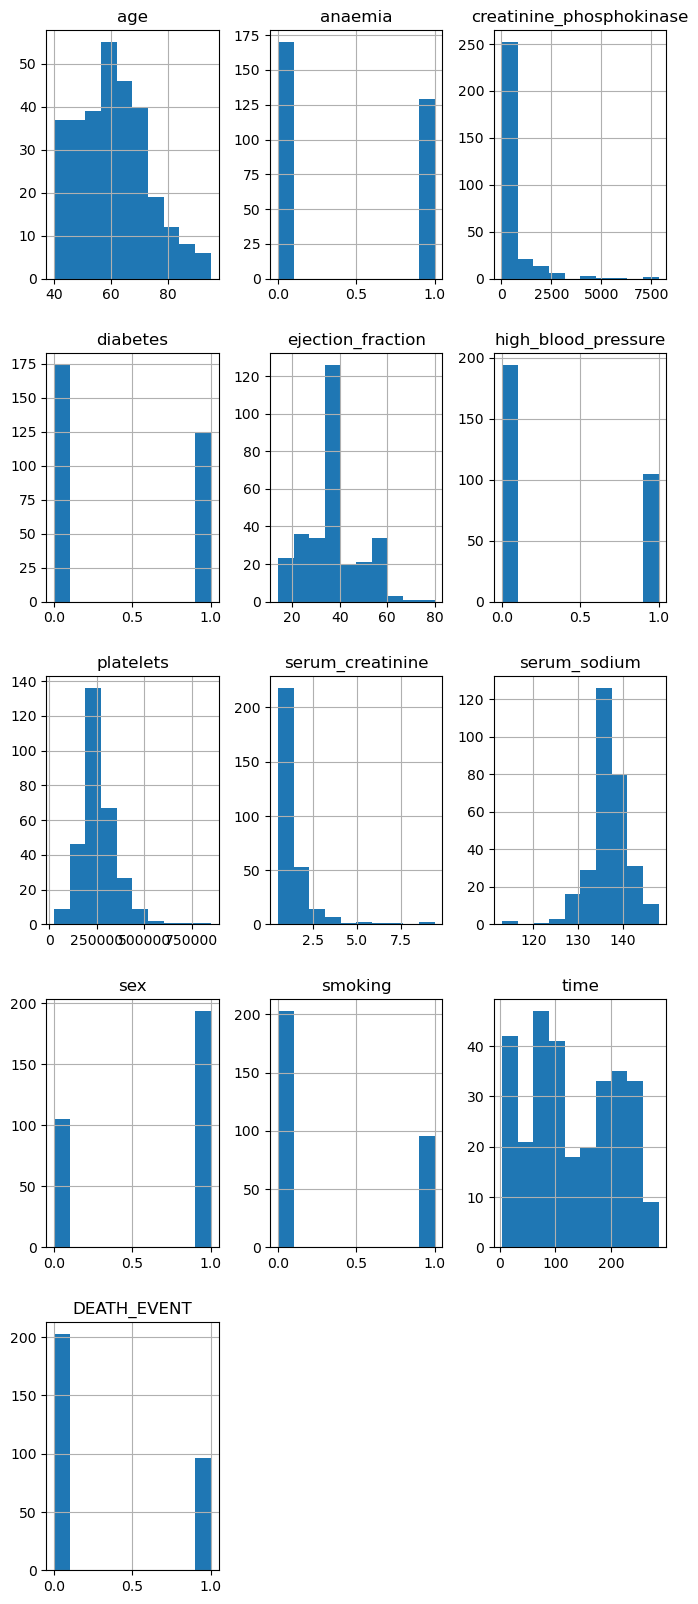

In [9]:
df.hist(layout=(5,3), figsize=(8,20))


### 2.3.1.1 Understanding distribution of target

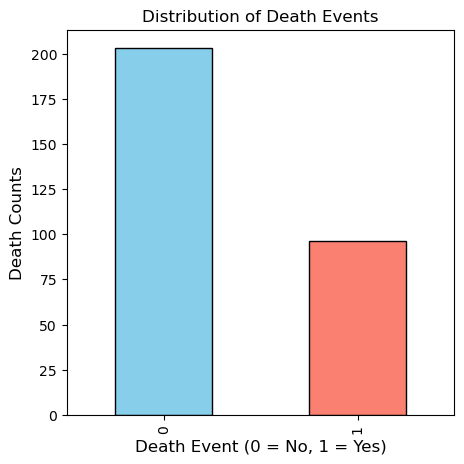

In [10]:
## Understanding distribution of target
df['DEATH_EVENT'].value_counts().plot(kind='bar',color=['skyblue', 'salmon'],  edgecolor='black',figsize=(5, 5))

plt.title('Distribution of Death Events')
plt.xlabel('Death Event (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Death Counts', fontsize=12)    
plt.show()

This shows that among the 299 patients, approximately 200 patients survived during the follow up period after they had heart failure, whereas the other 99 did not survive. 

### 2.3.1.2 Understanding distribution of features

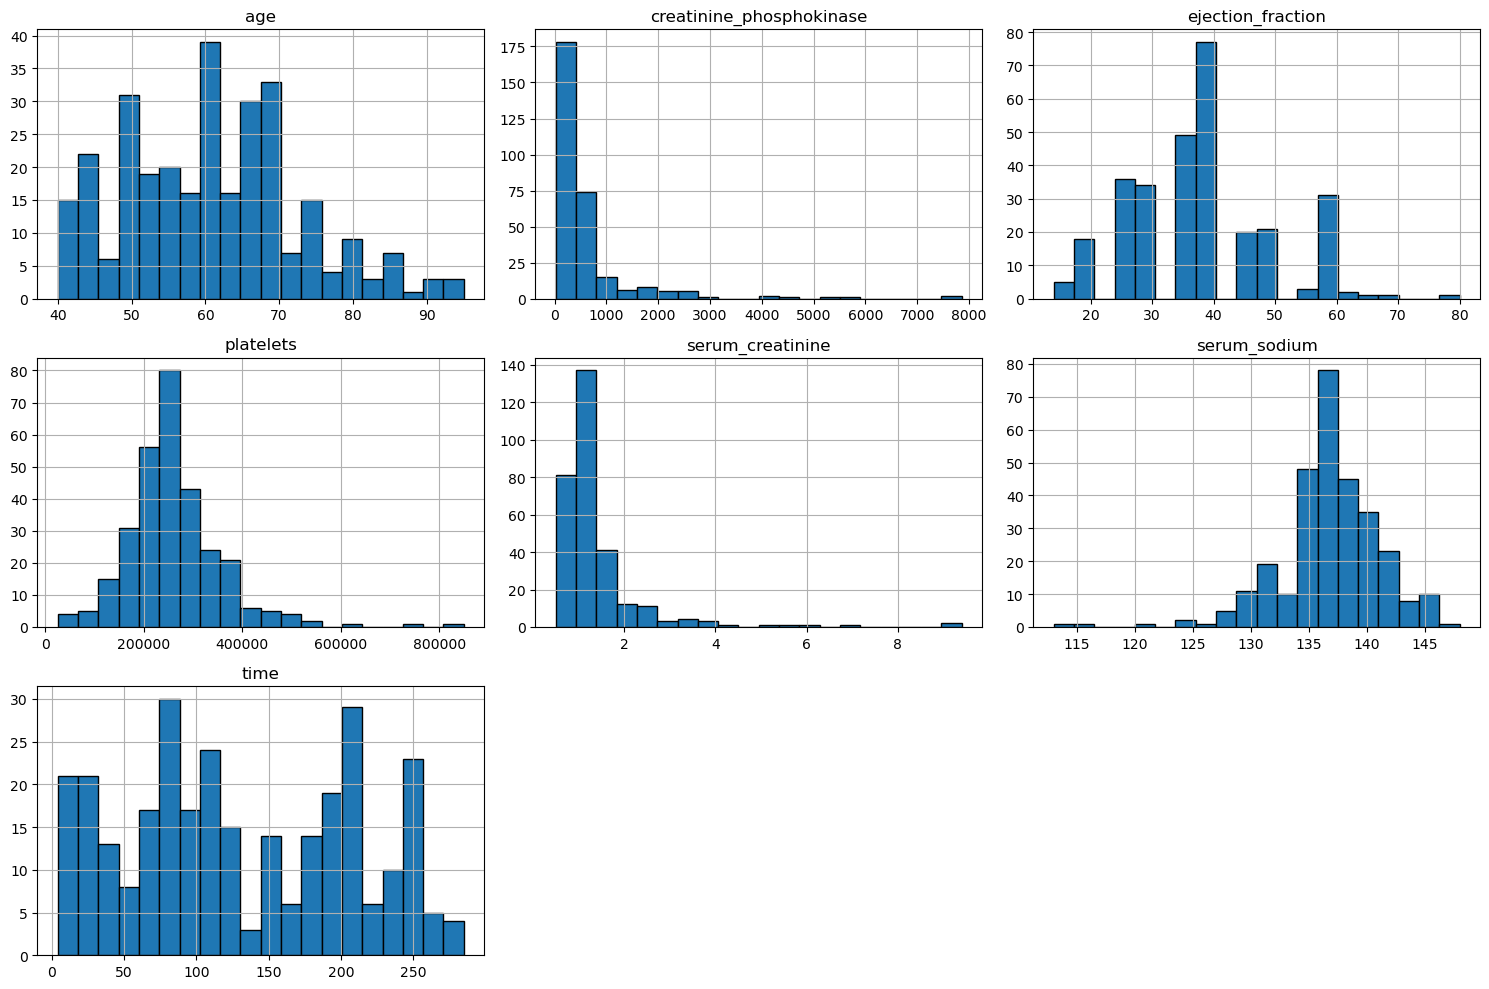

In [11]:
## Understanding distribution of features
numerical_features = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]

df[numerical_features].hist(
    figsize=(15,10),
    bins=20,
    edgecolor='black'
)

plt.tight_layout()
plt.show()

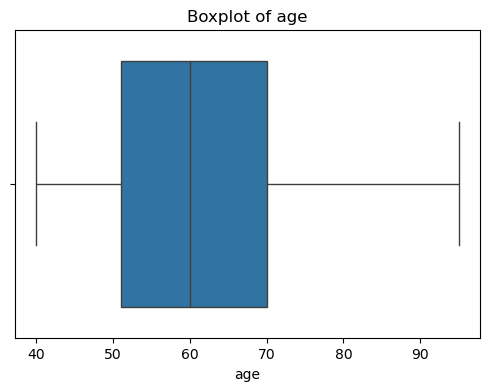

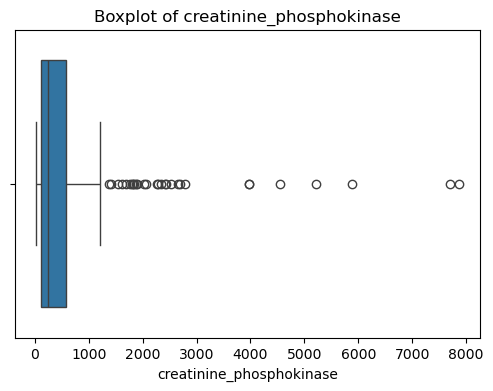

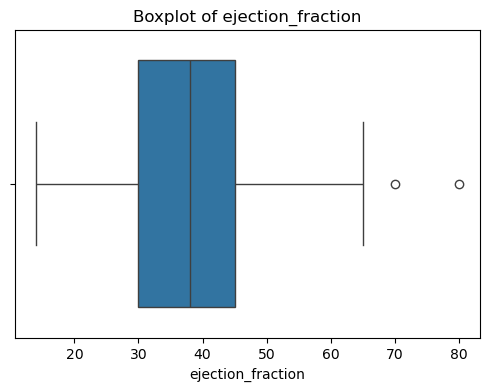

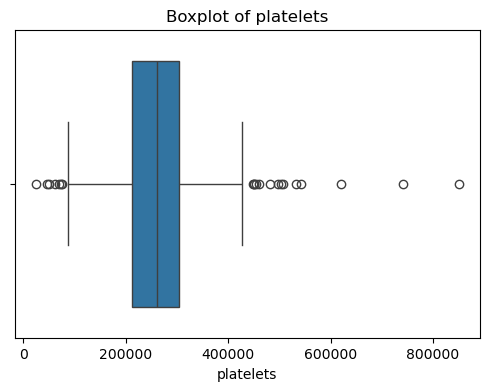

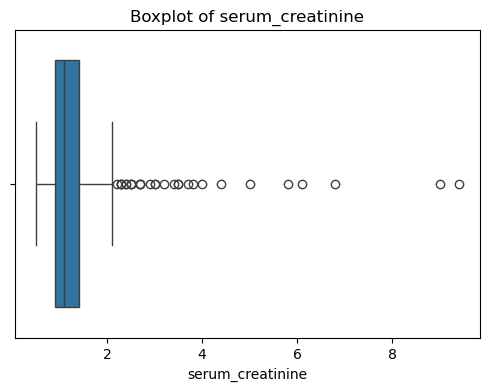

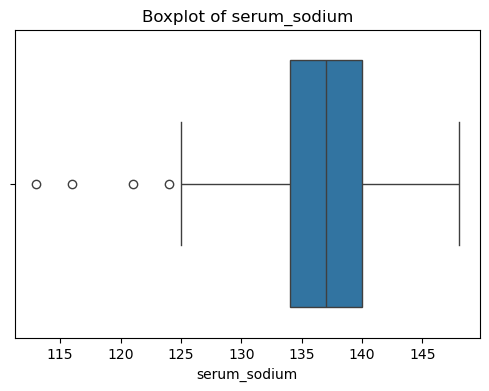

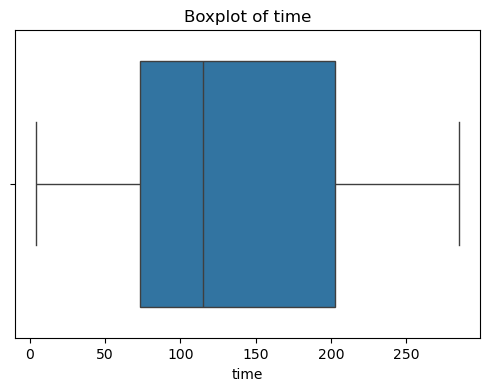

In [12]:
#Outliers
for column in numerical_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")

    plt.show()

The age distributuion is around the 60-years and the median age is 60 years. Most patients are between 50-70 years old.

For Creatinine Phosphokinase amd serum creatinine, the distribution is left-skewed, there are high or extreme outliers. While serum Sodium and platelets are distributed normally, there a few outliers.

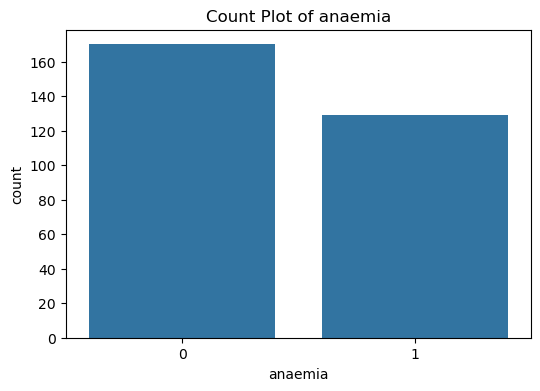

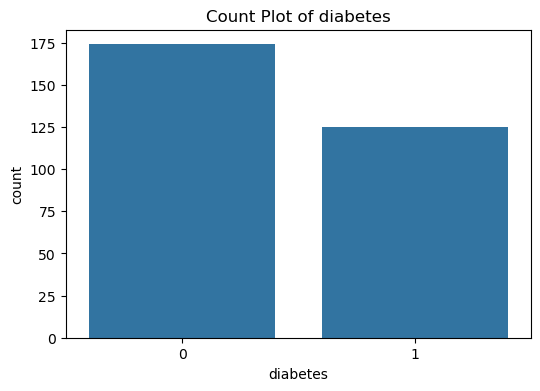

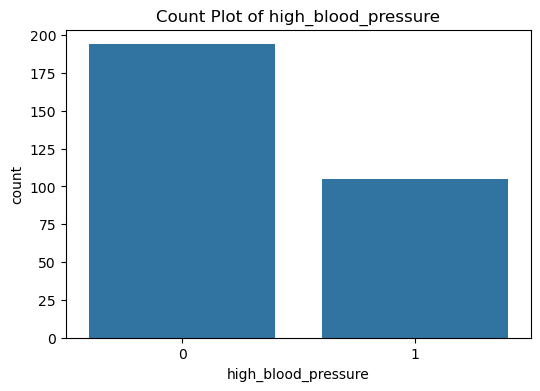

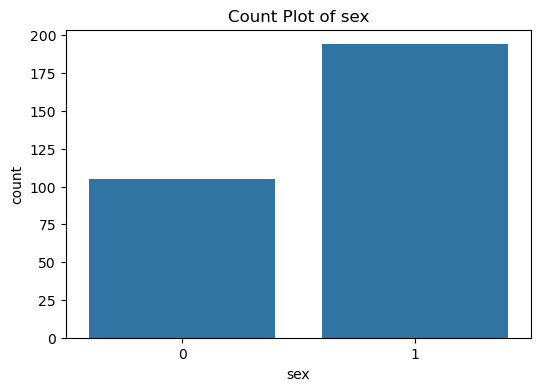

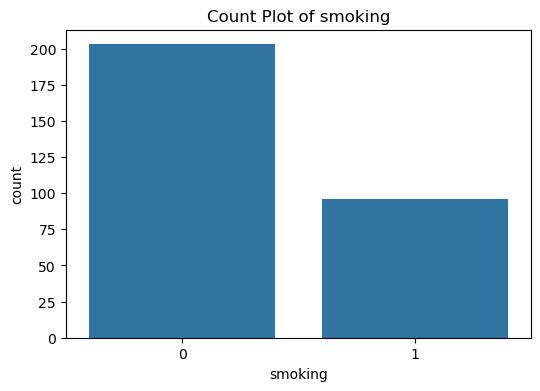

In [13]:
#Categorical
categorical_features = [
    'anaemia',
    'diabetes',
    'high_blood_pressure',
    'sex',
    'smoking'
]

for column in categorical_features:

    plt.figure(figsize=(6,4))

    sns.countplot(x=column, data=df)

    plt.title(f"Count Plot of {column}")

    plt.show()

### 2.3.2 Understanding relationship between variables

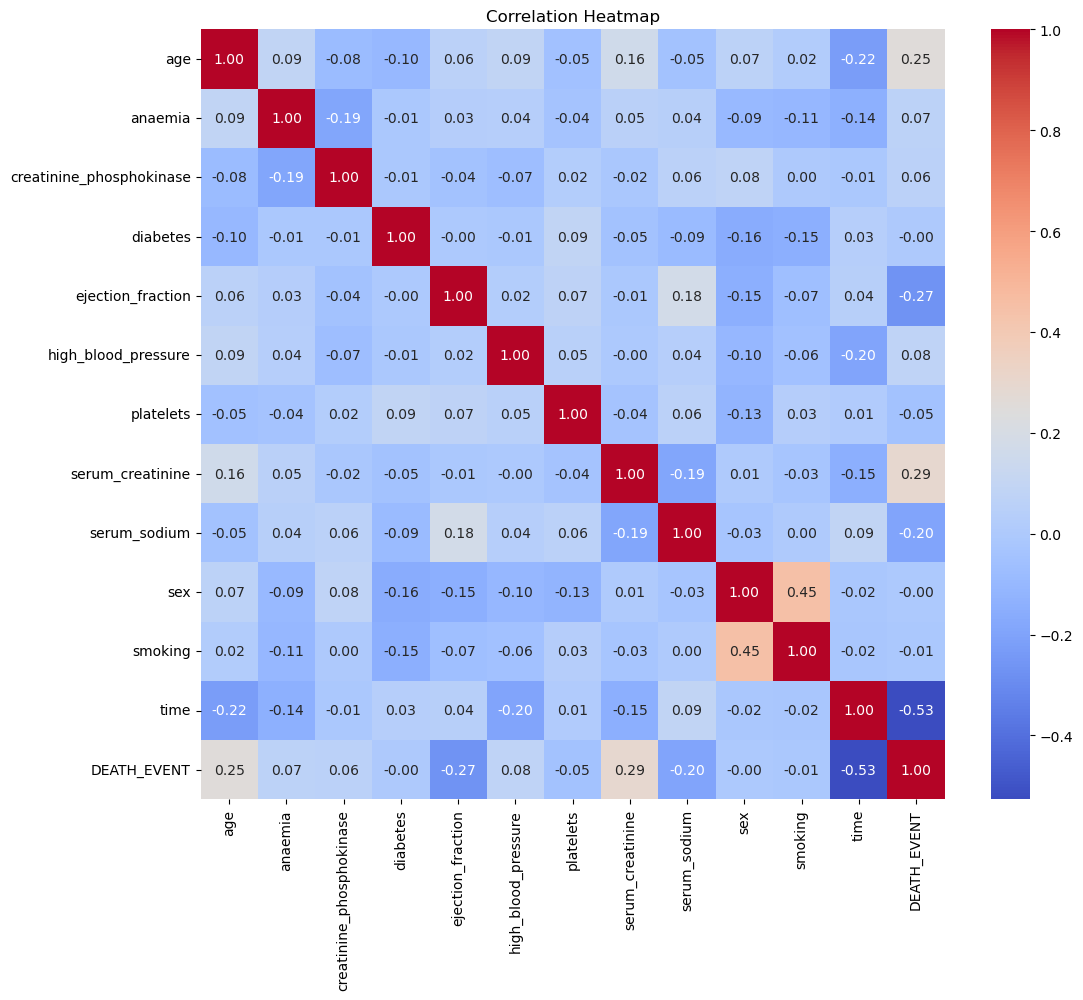

In [14]:
## Understanding relationship between variables
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In the heatmap, the features, smoking and sex as well as, time and DEATH_EVENT, have the highest correlation which each other, 0.45 and -0.53 respectively.
In addition, most of the features correlations with each other are close to 0.

In [15]:
correlation = df.corr()['DEATH_EVENT'].sort_values(ascending=False)
print(correlation)

DEATH_EVENT                 1.000000
serum_creatinine            0.294278
age                         0.253581
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
diabetes                   -0.001943
sex                        -0.004316
smoking                    -0.012623
platelets                  -0.049139
serum_sodium               -0.195204
ejection_fraction          -0.268603
time                       -0.526964
Name: DEATH_EVENT, dtype: float64


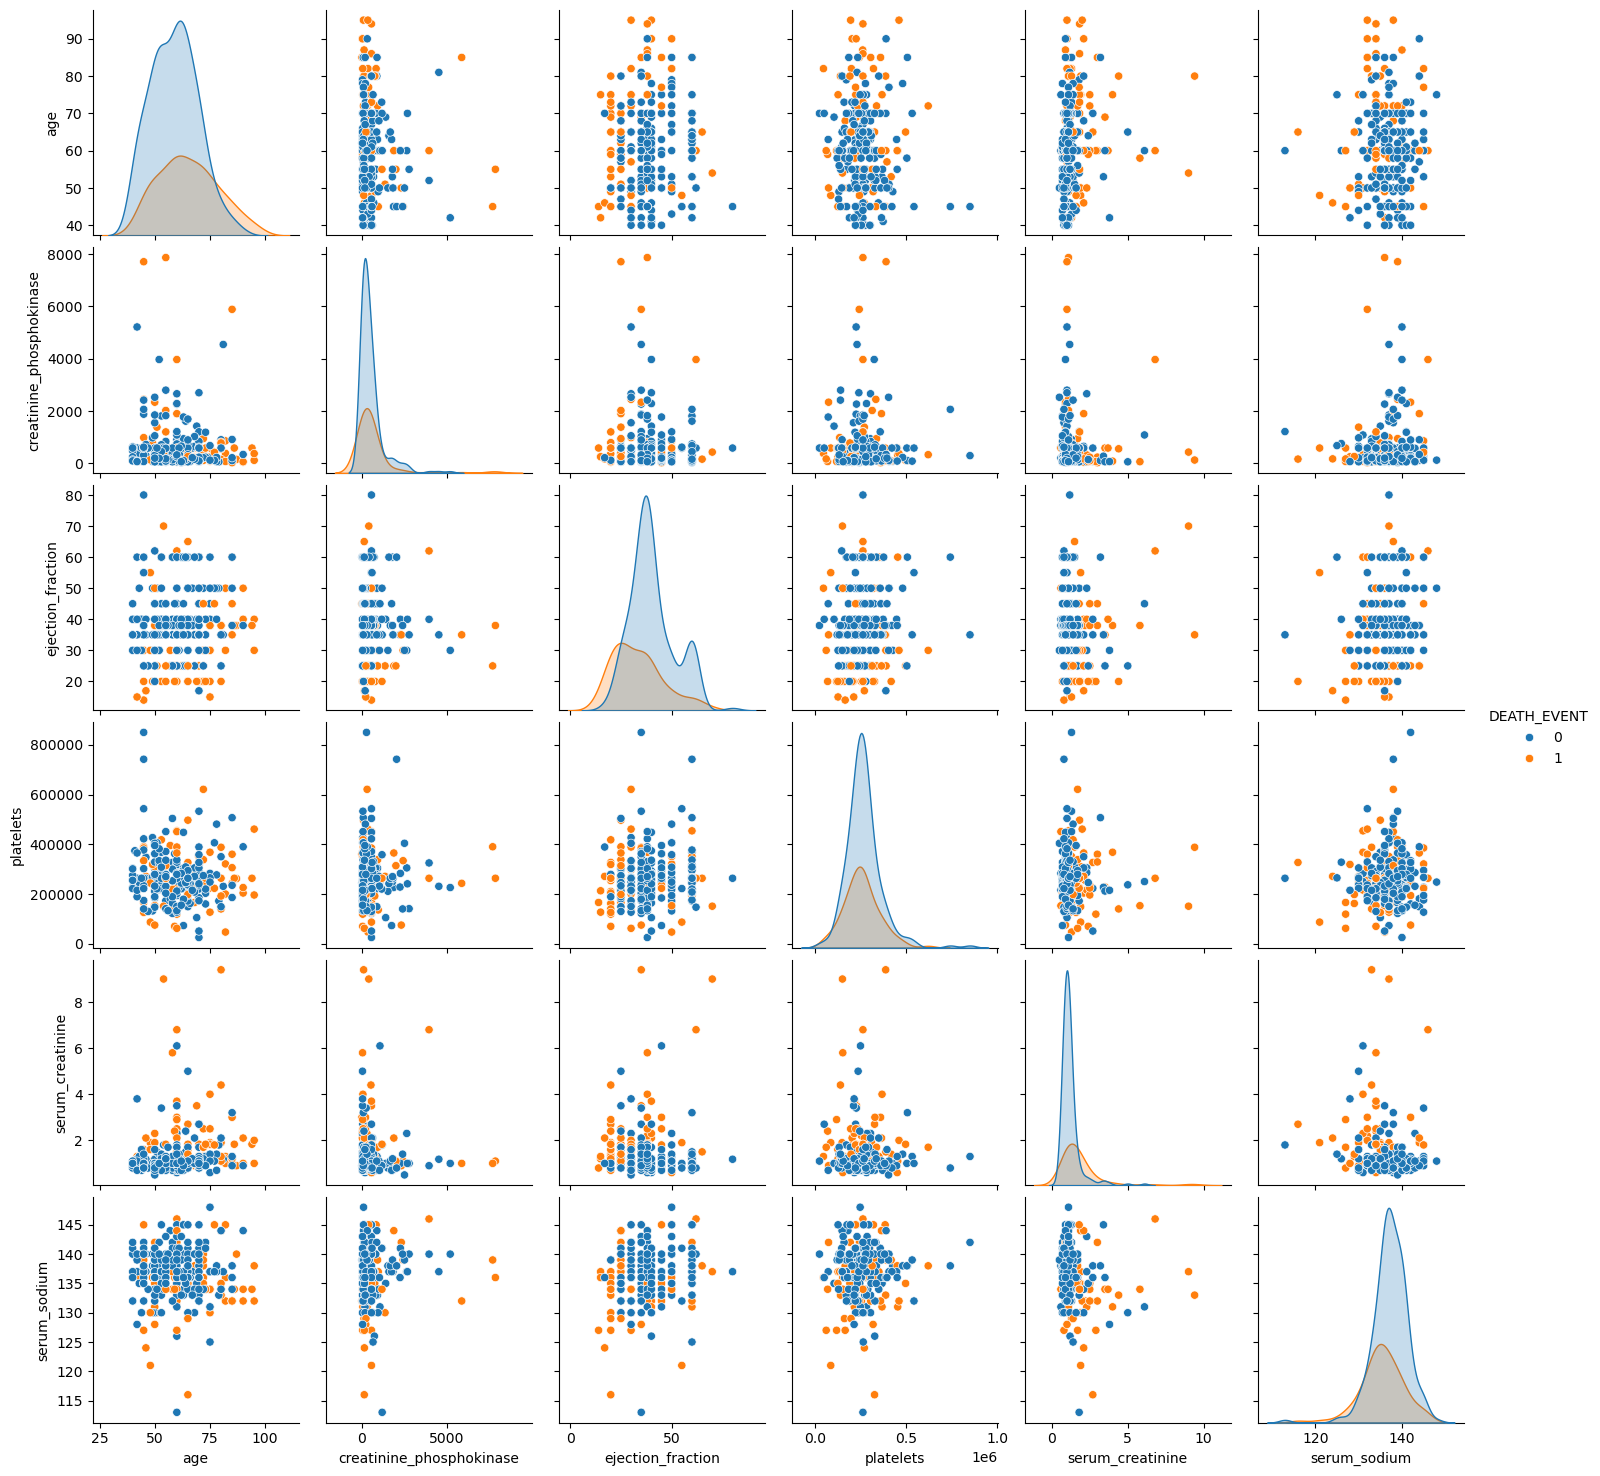

In [16]:
numerical_features = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium'
]

sns.pairplot(
    df[numerical_features + ['DEATH_EVENT']],
    hue='DEATH_EVENT',
)

plt.show()

Most of the feature pairs did not show strong linear correlations. However, patients with lower ejection fraction and higher serum creatinine showed that they were more likely experience a death event. Meanwhile Several numerical features, such as creatinine phosphokinase and serum creatinine, also exhibited noticeable outliers and skewed distributions

# 3. Data Preparation

## 3.1 Data Cleaning

In [17]:
## Clean data

There is no need for one-hot encoding because most of my categorical data are already represented as 0/1 values.

## 3.2 Train-Test Split

In [23]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split

X = df.drop(columns=['DEATH_EVENT'])
y = df['DEATH_EVENT']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. Modelling

### 4.2 Train Model

In [40]:
## Initialise and train model
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
"Logistic Regression": LogisticRegression(max_iter=1000),
"Decision Tree": DecisionTreeClassifier(random_state=42),
"Random Forest": RandomForestClassifier(random_state=42),
"Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 5. Model Evaluation

In [41]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, auc])

    print(f"\n{name}")

    print("Accuracy:", round(acc, 3))

    print("ROC-AUC:", round(auc, 3))

    print(classification_report(y_test, y_pred))

c:\Users\kawen\anaconda3\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
Accuracy: 0.833
ROC-AUC: 0.86
              precision    recall  f1-score   support

           0       0.83      0.95      0.89        41
           1       0.85      0.58      0.69        19

    accuracy                           0.83        60
   macro avg       0.84      0.77      0.79        60
weighted avg       0.83      0.83      0.82        60


Decision Tree
Accuracy: 0.733
ROC-AUC: 0.664
              precision    recall  f1-score   support

           0       0.78      0.85      0.81        41
           1       0.60      0.47      0.53        19

    accuracy                           0.73        60
   macro avg       0.69      0.66      0.67        60
weighted avg       0.72      0.73      0.72        60


Random Forest
Accuracy: 0.833
ROC-AUC: 0.892
              precision    recall  f1-score   support

           0       0.83      0.95      0.89        41
           1       0.85      0.58      0.69        19

    accuracy                           

out of all 4 classification models that i had chosen and evaluated with Accuracy, recall, Precision, F1-score and ROC-AUC, i chose Random Forest as it had the highest ROC-AUC (0.892) and still had the highest accuracy even as it was tied with logistic regression (0.833). 

Another reason i chose Random forest is because it is less prone to overfitting and showed a better distinguishability between patients who died and survived.

In [21]:
## New data

## Predict


## Iterative model development


In [22]:
## Further feature engineering / feature selection